# advection_diffusion.ipynb

#### Robert Peal March 2026

- An implementation of the advection diffusion equation for use in the UIBK MSc extension programme on mountain regions, lecture 3b: Modelling the atmosphere in complex terrain

#### Tracers in the atmosphere

- The atmosphere can sometimes carry small particles, like dust, water vapour, or smoke. These small particles are often known as tracers
- They can have significant impacts on air quality and so it is important to understand, when they are released, how they will affect the surroundings
    - see for example, the Nordkette fire (https://www.krone.at/3999265)
- This knowledge can inform us for example, if certain areas should be evacuated if the concentrations will become dangerously high

- The evolution of the concentration of these particles can be understood using the "advection-diffusion equation", which describes how the concentration of particulate matter in the atmosphere will change over time

#### The advection-diffusion equation in 2D

Solves:

$$
\frac{\partial C}{ \partial t} + u \frac{\partial C}{ \partial x} + v \frac{\partial C}{ \partial y} = K \left(\frac{\partial ^2 C}{ \partial x^2} + \frac{\partial ^2 C}{ \partial y^2}\right )
$$

where:

- $C(x, y, t)$ = tracer concentration (e.g. a pollutant)
- $u$, $v$ = wind components (m/s)
- $K$ = diffusivity parameter (m²/s), can be spatially varying


#### Breaking down the equation:

$$
\frac{\partial C}{ \partial t}
$$

is the time varying part. "How the value of C at every location in the model changes with time".

$$
u \frac{\partial C}{ \partial x} + v \frac{\partial C}{ \partial y}
$$

is the advection part - how the background wind field moves the particles through the domain

$$
K \left(\frac{\partial ^2 C}{ \partial x^2} + \frac{\partial ^2 C}{ \partial y^2}\right )
$$

is the diffusion part, how the particles spread out through the domain. Particles favourably move from areas of high concentration to low concentration.

#### Implementation notes

Numerical scheme:
- Advection:  first-order upwind (stable for CFL <= 1)
- Diffusion:  central differences (FTCS, stable for d <= 0.5)
- Time:       explicit forward Euler

This code is intentionally simple and readable.
Students are encouraged to experiment with the parameters below.

Author: prepared for "Modelling in Complex Terrain" lecture series by Robert Peal, with help from Claude

In [46]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [47]:


# =============================================================================
# 1.  GRID AND TIME SETUP
# =============================================================================

Lx = 10_000.0        # domain width  (m)
Ly = 10_000.0        # domain height (m)
nx = 100             # grid points in x
ny = 100             # grid points in y
dx = Lx / nx
dy = Ly / ny

x = np.linspace(0.5 * dx, Lx - 0.5 * dx, nx)   # cell centres
y = np.linspace(0.5 * dy, Ly - 0.5 * dy, ny)
X, Y = np.meshgrid(x, y)                         # shape (ny, nx)

dt        = 30.0       # time step (s)
n_steps   = 600        # number of steps to run
save_every = 10        # save a snapshot every N steps

In [78]:
# =============================================================================
# 2.  WIND FIELD  (experiment here!)
# =============================================================================
# Option A: uniform wind
u = 0.25 * np.ones((ny, nx))    # m/s  eastward
v = 0.0 * np.ones((ny, nx))    # m/s  northward

# # Option B: simple valley channelling — uncomment to try
u = 1. * np.sin(np.pi * Y / Ly)
v = np.zeros((ny, nx))

# Option C: a circular/vortex wind field — uncomment to try
# cx, cy = Lx / 2, Ly / 2
# u =  (Y - cy) / (Ly / 2) * 3.0
# v = -(X - cx) / (Lx / 2) * 3.0

Saved: advection_diffusion_wind_field.png


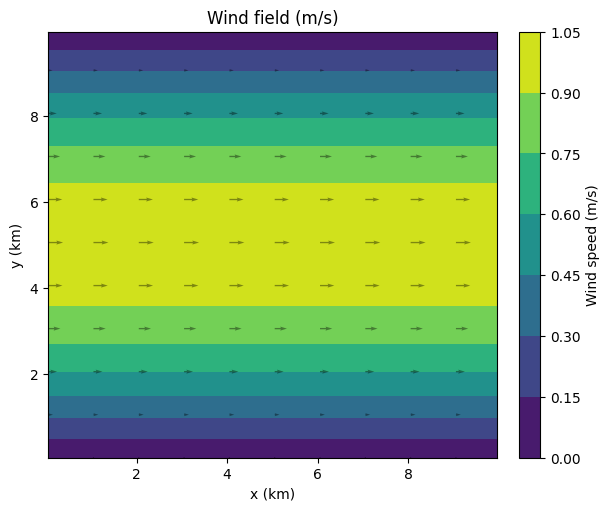

In [79]:
fig,ax=plt.subplots(figsize=(6, 5), constrained_layout=True)
im=ax.contourf(X / 1000, Y / 1000, np.sqrt(u**2 + v**2), cmap='viridis')
ax.quiver(X[::10, ::10] / 1000, Y[::10, ::10] / 1000,
               u[::10, ::10], v[::10, ::10],
               scale=30, width=0.003, alpha=0.4, color='black')
plt.colorbar(im,label="Wind speed (m/s)",alpha=1)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Wind field (m/s)")
plt.savefig("advection_diffusion_wind_field.png", dpi=150)
# plt.close()
print("Saved: advection_diffusion_wind_field.png")

In [80]:
# =============================================================================
# 3.  DIFFUSIVITY  (experiment here!)
# =============================================================================
# Option A: uniform K
K = 10.0 * np.ones((ny, nx))   # m²/s  (representative of stable valley BL)

# Option B: stronger mixing in the upper half of domain — uncomment to try
# K = np.where(Y > Ly / 2, 50.0, 5.0)

# Option C: K proportional to wind speed (crude turbulence parametrisation)
# wind_speed = np.sqrt(u**2 + v**2)
# K = 0.1 * wind_speed * dx      # mixing-length style

In [81]:
# =============================================================================
# 4.  STABILITY CHECK
# =============================================================================
CFL_x = np.max(np.abs(u)) * dt / dx
CFL_y = np.max(np.abs(v)) * dt / dy
d_x   = np.max(K) * dt / dx**2
d_y   = np.max(K) * dt / dy**2

print("=== Stability diagnostics ===")
print(f"  Courant number (x): {CFL_x:.3f}  {'OK' if CFL_x <= 1 else '*** UNSTABLE — reduce dt or increase dx ***'}")
print(f"  Courant number (y): {CFL_y:.3f}  {'OK' if CFL_y <= 1 else '*** UNSTABLE — reduce dt or increase dx ***'}")
print(f"  Diffusion number (x): {d_x:.4f}  {'OK' if d_x <= 0.5 else '*** UNSTABLE — reduce dt or K ***'}")
print(f"  Diffusion number (y): {d_y:.4f}  {'OK' if d_y <= 0.5 else '*** UNSTABLE — reduce dt or K ***'}")
print()

if CFL_x > 1 or CFL_y > 1 or d_x > 0.5 or d_y > 0.5:
    raise ValueError("Unstable configuration — adjust parameters before running.")

=== Stability diagnostics ===
  Courant number (x): 0.300  OK
  Courant number (y): 0.000  OK
  Diffusion number (x): 0.0300  OK
  Diffusion number (y): 0.0300  OK



In [82]:
# =============================================================================
# 5.  INITIAL CONDITION:  Gaussian concentration plume
# =============================================================================
x0 = 0.25 * Lx     # source location x (m)
y0 = 0.25 * Ly     # source location y (m)
sigma = 400.0       # initial plume width (m)

C = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

# Optional: add a second source — uncomment to try
# C += 0.5 * np.exp(-((X - 0.2*Lx)**2 + (Y - 0.3*Ly)**2) / (2*(sigma/2)**2))

In [83]:
# =============================================================================
# 6.  OBSTACLE / TERRAIN MASK  (experiment here!)
# =============================================================================
# A simple ridge running north-south through the centre of the domain.
# Cells inside the obstacle are set to zero concentration each step.
obstacle = np.zeros((ny, nx), dtype=bool)

# Uncomment to activate a ridge:
# ridge_x = 0.55 * Lx
# ridge_width = 300.0
# obstacle = np.abs(X - ridge_x) < ridge_width

In [84]:
# =============================================================================
# 7.  TIME INTEGRATION
# =============================================================================


def pad_zero(C):
    """
    Pad C with a border of zeros on all four sides (Dirichlet BC: C=0).
    This means any flux or gradient that reaches the domain edge sees
    zero concentration outside — tracer is absorbed at the boundary.
    """
    return np.pad(C, pad_width=1, mode='constant', constant_values=0.0)


def step(C, u, v, K, dx, dy, dt, obstacle):
    """
    Advance concentration C by one time step dt.

    Advection:  first-order upwind scheme
    Diffusion:  second-order centred (FTCS)
    Boundaries: Dirichlet zero (C=0 at all edges) — tracer is absorbed
                at the boundary; no re-entry from outside the domain.
    """
    # Pad with zeros to enforce C=0 outside the domain
    Cp = pad_zero(C)   # shape (ny+2, nx+2)
    up = pad_zero(u)
    vp = pad_zero(v)
    Kp = pad_zero(K)

    # Interior slice indices (the original domain)
    i = np.s_[1:-1, 1:-1]   # centre
    im1x = np.s_[1:-1, :-2] # one step left  (i-1 in x)
    ip1x = np.s_[1:-1, 2:]  # one step right (i+1 in x)
    im1y = np.s_[:-2, 1:-1] # one step down  (j-1 in y)
    ip1y = np.s_[2:, 1:-1]  # one step up    (j+1 in y)

    # --- Advection (upwind) ---
    # x-direction: use upstream neighbour based on sign of u
    flux_x_l = up[i] * Cp[im1x]   # u > 0: wind from left, use left cell
    flux_x_r = up[i] * Cp[ip1x]   # u < 0: wind from right, use right cell
    flux_x   = np.where(up[i] >= 0, flux_x_l, flux_x_r)

    # x-direction flux at right face (i+1/2)
    flux_x_l_r = up[ip1x] * Cp[i]
    flux_x_r_r = up[ip1x] * Cp[ip1x]
    flux_x_right = np.where(up[ip1x] >= 0, flux_x_l_r, flux_x_r_r)

    adv_x = (flux_x_right - flux_x) / dx

    # y-direction
    flux_y_d = vp[i] * Cp[im1y]
    flux_y_u = vp[i] * Cp[ip1y]
    flux_y   = np.where(vp[i] >= 0, flux_y_d, flux_y_u)

    flux_y_top_d = vp[ip1y] * Cp[i]
    flux_y_top_u = vp[ip1y] * Cp[ip1y]
    flux_y_top   = np.where(vp[ip1y] >= 0, flux_y_top_d, flux_y_top_u)

    adv_y = (flux_y_top - flux_y) / dy

    # --- Diffusion (central differences) ---
    d2Cdx2 = (Cp[ip1x] - 2*Cp[i] + Cp[im1x]) / dx**2
    d2Cdy2 = (Cp[ip1y] - 2*Cp[i] + Cp[im1y]) / dy**2
    diff = Kp[i] * (d2Cdx2 + d2Cdy2)

    C_new = C + dt * (-adv_x - adv_y + diff)

    # Zero out obstacle cells
    C_new[obstacle] = 0.0

    # Clip to avoid tiny negative values from numerical diffusion
    C_new = np.clip(C_new, 0.0, None)

    return C_new

In [85]:
snapshots = [C.copy()]
times     = [0.0]

for n in range(n_steps):
    C = step(C, u, v, K, dx, dy, dt, obstacle)
    if (n + 1) % save_every == 0:
        snapshots.append(C.copy())
        times.append((n + 1) * dt)

print(f"Integration complete: {n_steps} steps, {n_steps * dt / 60:.1f} minutes simulated.")

Integration complete: 600 steps, 300.0 minutes simulated.


In [87]:
# =============================================================================
# 8.  VISUALISATION
# =============================================================================

# --- Static: first, middle, last snapshot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
indices = [0, len(snapshots) // 2, -1]
for ax, idx in zip(axes, indices):
    vmax = np.max(snapshots[idx]) or 1.0
    im = ax.pcolormesh(x / 1000, y / 1000, snapshots[idx],
                       cmap='YlOrRd', vmin=0, vmax=vmax, shading='auto')
    if obstacle.any():
        ax.contourf(X / 1000, Y / 1000, obstacle.astype(float),
                    levels=[0.5, 1.5], colors='grey', alpha=0.6)
    ax.quiver(X[::10, ::10] / 1000, Y[::10, ::10] / 1000,
              u[::10, ::10], v[::10, ::10],
              scale=20, width=0.003, alpha=0.4, color='steelblue')
    ax.set_title(f"t = {times[idx]/60:.1f} min")
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    plt.colorbar(im, ax=ax, label="C (normalised)")

fig.suptitle("2D Advection-Diffusion: tracer evolution", fontsize=13)
plt.savefig("advection_diffusion_snapshots.png", dpi=150)
plt.close()
print("Saved: advection_diffusion_snapshots.png")

# --- Animation ---
fig_anim, ax_anim = plt.subplots(figsize=(6, 5), constrained_layout=True)
im_anim = ax_anim.pcolormesh(x / 1000, y / 1000, snapshots[0],
                              cmap='YlOrRd', vmin=0,
                              vmax=np.max(snapshots[0]), shading='auto')
if obstacle.any():
    ax_anim.contourf(X / 1000, Y / 1000, obstacle.astype(float),
                     levels=[0.5, 1.5], colors='grey', alpha=0.6)
ax_anim.quiver(X[::10, ::10] / 1000, Y[::10, ::10] / 1000,
               u[::10, ::10], v[::10, ::10],
               scale=20, width=0.003, alpha=0.4, color='steelblue')
plt.colorbar(im_anim, ax=ax_anim, label="C (normalised)")
ax_anim.set_xlabel("x (km)")
ax_anim.set_ylabel("y (km)")
title_anim = ax_anim.set_title("t = 0.0 min")


def update(frame):
    data = snapshots[frame]
    vmax = np.max(snapshots[0])
    im_anim.set_array(data.ravel())
    im_anim.set_clim(vmin=0, vmax=vmax)
    title_anim.set_text(f"t = {times[frame]/60:.1f} min")
    return im_anim, title_anim


ani = animation.FuncAnimation(fig_anim, update, frames=len(snapshots),
                               interval=80, blit=True)
ani.save("advection_diffusion_animation.gif",
         writer='pillow', fps=12)
plt.close()
print("Saved: advection_diffusion_animation.gif")

Saved: advection_diffusion_snapshots.png
Saved: advection_diffusion_animation.gif
